In [1]:
!pip install 'powerlaw'
!pip install 'whittlehurst'

import bmll2 as b2
from bmll2 import reference, Security, NormalisedSecurity, SparkHelper, get_market_data, get_market_data_range, VenueMarketError, get_market_tables, save_spark_dataframe, load_spark_dataframe
b2.get_file('modules/auxiliary_functions.py')
b2.get_file('modules/auxiliary_functions_polars.py')
import auxiliary_functions as af
import auxiliary_functions_polars as af_pl

import random
import math
import pandas as pd
import polars as pl
import numpy as np
from pandas import StringDtype
from datetime import timedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogFormatterSciNotation

from statsmodels.sandbox.stats.runs import runstest_1samp 
import powerlaw
import itertools
import pylab
import scipy.stats
import scipy.fft
from scipy.optimize import curve_fit
from sklearn.model_selection import ParameterGrid

from statsmodels.tsa.stattools import acf
from whittlehurst import whittle, fbm, tdml
from scipy.stats import t

from typing import Literal


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.8/567.8 kB 53.8 MB/s eta 0:00:00


In [ ]:
""""
files = b2.list_files(path = 'data/grid_search_5/XJSE')
for f in files:
    b2.get_file(f'data/grid_search_5/XJSE/{f}')
# Move each file
for f in files:
    print(f)
    try:
        b2.put_file(f, 'data/grid_search_6/XJSE/power')
    except FileNotFoundError:
        print('skipping', f)
""""

In [2]:
%%time
participation_method = 'power'
exchange = 'XJSE'
files = b2.list_files(path = f'data/grid_search_6/{exchange}/{participation_method}')

for f in files:
    b2.get_file(f'data/grid_search_6/{exchange}/{participation_method}/{f}')

CPU times: user 3.25 s, sys: 110 ms, total: 3.36 s
Wall time: 40.3 s


In [10]:
data = pl.read_parquet('ABG_XJSE_grid_search.parquet')
data.head(25)

year,ticker,N,delta,xmin,alpha,gamma (nlls),gamma (psd),impact curve exponent,impact curve exponent var,impact curve half width,phi exponent,phi exponent var,phi exponent half width,beta,beta var,beta half width
i64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023,"""ABG""",50,1.5,8.0,1.873657,0.593499,0.573213,0.076861,0.001205,0.07046,1.052668,0.000939,0.061623,0.10628,0.000001,0.002342
2024,"""ABG""",50,1.5,11.0,1.958383,0.567097,0.491666,0.167728,0.000753,0.055887,1.019078,0.000654,0.051419,0.125513,0.000002,0.003098
2025,"""ABG""",50,1.5,9.0,1.955029,0.60662,0.569207,0.128391,0.001247,0.071559,1.032954,0.000916,0.060869,0.117173,0.000002,0.002756
2023,"""ABG""",50,2.0,3.0,1.74585,0.593499,0.573213,0.066132,0.000826,0.058328,0.999433,0.000895,0.060135,0.142765,0.000007,0.00519
2024,"""ABG""",50,2.0,4.0,1.90874,0.567097,0.491666,0.087907,0.000859,0.059706,1.001593,0.000988,0.063187,0.175033,0.000007,0.005227
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025,"""ABG""",100,2.0,3.0,1.983594,0.60662,0.569207,0.09163,0.001372,0.075119,0.955842,0.001343,0.073672,0.155679,0.000004,0.003871
2023,"""ABG""",100,3.0,2.0,1.642651,0.593499,0.573213,9.072623,186083.919448,875.736699,0.874472,0.001309,0.072734,0.09556,0.000067,0.016403
2024,"""ABG""",100,3.0,2.0,1.599036,0.567097,0.491666,0.137875,0.000864,0.059959,0.791039,0.000907,0.060547,0.216932,0.000037,0.012239


In [3]:
data = pl.scan_parquet('*_XJSE_grid_search.parquet').collect()

if participation_method == 'homogenous':
    data.sort(['ticker', 'year', 'N'])
    data.head(10)
if participation_method == 'power':
    data.sort(['ticker', 'year', 'N', 'delta'])
    data.head(10)

In [4]:
data.head()

year,ticker,N,delta,xmin,alpha,gamma (nlls),gamma (psd),impact curve exponent,impact curve exponent var,impact curve half width,phi exponent,phi exponent var,phi exponent half width,beta,beta var,beta half width
i64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023,"""4SI""",50,1.5,3.0,1.632324,0.967303,1.03571,0.331471,0.009991,0.204131,0.202451,0.039819,0.401906,0.38274,0.000641,0.050912
2024,"""4SI""",50,1.5,2.0,1.222273,0.933238,0.62871,0.351366,0.012125,0.225556,0.909088,0.027089,0.330924,0.170914,0.000078,0.01777
2025,"""4SI""",50,1.5,3.0,1.680371,0.32857,0.574836,0.170615,0.002119,0.093649,0.334226,0.028434,0.339043,0.130089,0.000094,0.019448
2024,"""4SI""",50,2.0,3.0,1.796021,0.933238,0.62871,0.152021,0.003955,0.129797,1.457715,0.502354,1.42937,0.012328,0.000064,0.016101
2023,"""4SI""",100,1.5,2.0,1.272424,0.967303,1.03571,0.539474,0.054791,0.479481,0.329647,0.130098,0.731515,0.412969,0.001072,0.065844


In [8]:
"""
data.write_csv('calibration_results.csv')
b2.put_file('calibration_results.csv', 'data/grid_search_2/XJSE/')
"""

In [5]:
# the error is calculated as |estimate - expected_value| + lambda * var
# estimate = the estimated value
# expected_value = the expectd_value for the point estimate
# var = the variance of the point estimate
# lambda_penalty = the penalty term that the variance should be multiplied by

def error_calculation(estimate, expected_value, var, lambda_penalty = 1):
    error = np.abs(estimate - expected_value)
    ans   = error + lambda_penalty * var
    return ans

In [6]:
# returns a dataframe that contains the best configuration for each time scale
# data = dataframe containing the configurations details with estimates for the exponents with variances and interval half widths
# config = do you want the configuration that fits the microscopic/macroscopic values the best. Microscopic refers to the impact curve exponent
# the phi exponent and beta
# estimation_method = wether you want the results for when gamma is estimated using the NLLS or the PSD method
# lambda_penatly = the penalty term for the variance
# mix = how the ratio that individual errors for the impact curve exponent, exponent for phi, and beta should be mixed to get the total macroscopic error

def find_configs(data, participation_method, config = Literal['metaorder', 'LMF'],
                   estimation_method = Literal['NLLS', 'PSD'], lambda_penalty = 1, mix = [1, 1, 1]):

    impact_error = error_calculation(data[:, 'impact curve exponent'], 0.5, data[:, 'impact curve exponent var'], lambda_penalty)
    phi_error    = error_calculation(data[:, 'phi exponent'], 0.5, data[:, 'phi exponent var'], lambda_penalty)
    gamma        = data[:, f'gamma ({estimation_method.lower()})']
    beta_error   = error_calculation(data[:, 'beta'], 0.5 * (1 - gamma), data[:, 'beta var'], lambda_penalty)
    alpha_error  = np.abs(data[:, 'alpha'] - 1 - gamma)

    if participation_method == 'homogenous':
        error_df = pl.DataFrame({'year': data.select('year'), 'ticker': data.select('ticker'), 'N': data.select('N'),
                                 #f'$\\delta$': data.select('delta'), 
                                 f'$\\alpha$': data.select('alpha'), 
                                 f'$\\gamma$': data.select(f'gamma ({estimation_method.lower()})'),
                                 f'\\makecell{{$\\frac{{Q}}{{V_D}}$ \\\\ exponent}}': data.select('impact curve exponent'),
                                 f'\\makecell{{$\\phi$ \\\\ exponent}}': data.select('phi exponent'), 
                                 f'$\\beta$': data.select('beta'), 
                                 f'$\\mathrm{{e}}_{{M}}$ ({estimation_method})': (mix[0] * impact_error + mix[1] * phi_error + mix[2] * beta_error) / sum(mix),
                                 f'$\\mathrm{{e}}_{{LMF}}$ ({estimation_method})': alpha_error})
    
    if participation_method == 'power':
        error_df = pl.DataFrame({'year': data.select('year'), 'ticker': data.select('ticker'), 'N': data.select('N'),
                                 f'$\\delta$': data.select('delta'), 
                                 f'$\\alpha$': data.select('alpha'), 
                                 f'$\\gamma$': data.select(f'gamma ({estimation_method.lower()})'),
                                 f'\\makecell{{$\\frac{{Q}}{{V_D}}$ \\\\ exponent}}': data.select('impact curve exponent'),
                                 f'\\makecell{{$\\phi$ \\\\ exponent}}': data.select('phi exponent'), 
                                 f'$\\beta$': data.select('beta'), 
                                 f'$\\mathrm{{e}}_{{M}}$ ({estimation_method})': (mix[0] * impact_error + mix[1] * phi_error + mix[2] * beta_error) / sum(mix),
                                 f'$\\mathrm{{e}}_{{LMF}}$ ({estimation_method})': alpha_error})
        
    if (config == 'metaorder'):
        error_df = error_df.sort(f'$\\mathrm{{e}}_{{M}}$ ({estimation_method})').group_by(['ticker', 'year']).first()
        error_df = error_df.sort(['ticker', 'year'])
        return error_df

    if (config == 'LMF'):
        error_df = error_df.sort(f'$\\mathrm{{e}}_{{LMF}}$ ({estimation_method})').group_by(['ticker', 'year']).first()
        error_df = error_df.sort(['ticker', 'year'])
        return error_df

In [12]:
GFI_configs = find_configs(data = data, participation_method = 'power',
                           config = 'metaorder', estimation_method = 'PSD',
                           lambda_penalty = 1, mix = [1, 1, 1]).filter(pl.col('ticker') == 'GRT')
GFI_configs

ticker,year,N,$\delta$,$\alpha$,$\gamma$,\makecell{$\frac{Q}{V_D}$ \\ exponent},\makecell{$\phi$ \\ exponent},$\beta$,$\mathrm{e}_{M}$ (PSD),$\mathrm{e}_{LMF}$ (PSD)
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""GRT""",2023,50,3.0,1.531323,0.482646,0.066946,0.803252,0.191449,0.268493,0.048677
"""GRT""",2024,100,3.0,1.549268,0.433737,0.100366,0.656184,0.119316,0.240767,0.115531
"""GRT""",2025,500,2.0,1.522095,0.489648,0.124153,0.734745,0.129374,0.246674,0.032447


In [24]:
print(GFI_configs.to_pandas().to_latex(index = False, float_format = '%.2f'))

\begin{tabular}{lrrrrrrrrr}
\toprule
ticker & year & N & $\alpha$ & $\gamma$ & \makecell{$\frac{Q}{V_D}$ \\ exponent} & \makecell{$\phi$ \\ exponent} & $\beta$ & $\mathrm{e}_{M}$ (PSD) & $\mathrm{e}_{LMF}$ (PSD) \\
\midrule
GRT & 2023 & 50 & 1.54 & 0.48 & 0.05 & 0.79 & 0.21 & 0.26 & 0.06 \\
GRT & 2024 & 1500 & 1.54 & 0.43 & 1.20 & 0.45 & 0.15 & 3.10 & 0.10 \\
GRT & 2025 & 40 & 1.53 & 0.49 & 0.07 & 0.71 & 0.14 & 0.25 & 0.04 \\
\bottomrule
\end{tabular}



In [7]:
def process_stock_pl(stock_data, group = 'day', N = 4, participation_method = 'homogenous', alpha = 2):

    if group == 'day':
        stock_data = stock_data.with_columns(pl.col('Date').alias('group key'))

    elif group == 'month':
        stock_data = stock_data.with_columns(pl.col('Date').dt.truncate('1mo').alias('group key'))
    
    elif group == 'year':
        stock_data = stock_data.with_columns(pl.col('Date').dt.truncate('1y').alias('group key'))

    groups = stock_data.select('group key').unique().sort('group key').to_series().to_list()

    if isinstance(N, list):
        if len(N) != len(groups):
            raise ValueError('Length of N list must match number of groups')
        N_map = dict(zip(groups, N))
    else:
        N_map = {g: N for g in groups}

    if isinstance(alpha, list):
        if len(alpha) != len(groups):
            raise ValueError('Length of alpha list must match number of groups')
        alpha_map = dict(zip(groups, alpha))
    else:
        alpha_map = {g: alpha for g in groups}
        
    features_list_pl = []
    
    for trades in stock_data.partition_by('group key'):

        if trades.is_empty():
            continue

        trades = trades.sort(['DateTime', 'ExchangeSequenceNo'])

        group_value = trades['group key'][0]
        N_val       = N_map[group_value]
        alpha_val   = alpha_map[group_value]
        
        f      = af_pl.trader_participation(N = N_val, method = participation_method, alpha = alpha_val, f_min = 1,
                                            f_max = trades.shape[0], seed = 1)
        c      = af_pl.cumulative_probs(f)
        output = af_pl.orders(N = N_val, trades = trades, cumulative_probs = c)
        
        assignments = []
        for trader_id, rows in enumerate(output):
            for r in rows:
                assignments.append((r, trader_id))

        assignments_df = pl.DataFrame(assignments, schema = ['row idx', 'trader id'], orient = 'row')

        trades = trades.with_row_index('row idx')
        trades = trades.join(assignments_df, on = 'row idx', how = 'inner')
        trades = trades.sort(['DateTime', 'ExchangeSequenceNo'])

        trades = trades.with_columns((pl.col('Trade Sign') != pl.col('Trade Sign').shift(1)).cast(pl.Int32)
            .cum_sum().over(['Date', 'trader id']).alias('metaorder id'))
        

        features = trades.group_by(['Date', 'trader id', 'metaorder id']
        ).agg([

            pl.col('Ticker').first(),
            pl.col('MIC').first(),
            pl.col('DateTime').first().alias('Start time'),
            pl.col('DateTime').last().alias('End time'),

            pl.col('Daily Volume').first(),
            pl.col('Intraday Volatility').first(),
            pl.col('20 AD volume').first(),
            pl.col('20 AD volatility').first(),

            pl.col('Trade Sign').first().alias('trade sign'),
            
            pl.col('Volume').sum().alias('volume traded'),
            pl.len().alias('number child orders'),
            
            pl.col('Mid-price before').first(),
            pl.col('Mid-price after').last(),
            pl.col('Mid-price after (delayed)').last(),
            
            pl.col('Mid-price before (1ms)').first(),
            pl.col('Mid-price after (1ms)').last(),
            pl.col('Mid-price after (1ms)(delayed)').last()
        ])

        features = features.filter(pl.col('number child orders') > 1)

        features = features.with_columns([
            ((pl.col('Mid-price after').log() - pl.col('Mid-price before').log())
             * pl.col('trade sign')).alias('impact'),
        
            ((pl.col('Mid-price after (delayed)').log() - pl.col('Mid-price before').log())
             * pl.col('trade sign')).alias('impact (delayed)'),
        
            ((pl.col('Mid-price after (1ms)').log() - pl.col('Mid-price before (1ms)').log())
             * pl.col('trade sign')).alias('impact (1ms)'),
        
            ((pl.col('Mid-price after (1ms)(delayed)').log() - pl.col('Mid-price before (1ms)').log())
             * pl.col('trade sign')).alias('impact (1ms)(delayed)'), 
            
            (((pl.col('End time') - pl.col('Start time')).dt.total_microseconds() / 6e7).alias('duration (min)'))
        ])
        
        features_list_pl.append(features)

    if features_list_pl:
        return pl.concat(features_list_pl, how = 'vertical', rechunk = True)
    else:
        return pl.DataFrame()


def concave_profile_pl(stock_data, group = 'day', N = 4, participation_method = 'homogenous', alpha = 2):

    if group == 'day':
        stock_data = stock_data.with_columns(pl.col('Date').alias('group key'))

    elif group == 'month':
        stock_data = stock_data.with_columns(pl.col('Date').dt.truncate('1mo').alias('group key'))
    
    elif group == 'year':
        stock_data = stock_data.with_columns(pl.col('Date').dt.truncate('1y').alias('group key'))
    
    groups = stock_data.select('group key').unique().sort('group key').to_series().to_list()
    
    if isinstance(N, list):
        if len(N) != len(groups):
            raise ValueError('Length of N list must match number of groups')
        N_map = dict(zip(groups, N))
    else:
        N_map = {g: N for g in groups}

    if isinstance(alpha, list):
        if len(alpha) != len(groups):
            raise ValueError('Length of alpha list must match number of groups')
        alpha_map = dict(zip(groups, alpha))
    else:
        alpha_map = {g: alpha for g in groups}
        
    impact_profile = []
    
    for trades in stock_data.partition_by('group key'):
        
        if trades.is_empty():
            continue

        trades = trades.sort(['DateTime', 'ExchangeSequenceNo'])

        group_value = trades['group key'][0]
        N_val       = N_map[group_value]
        alpha_val   = alpha_map[group_value]
        
        f      = af_pl.trader_participation(N = N_val, method = participation_method, alpha = alpha_val, f_min = 1,
                                            f_max = trades.shape[0], seed = 1)
        c      = af_pl.cumulative_probs(f)
        output = af_pl.orders(N = N_val, trades = trades, cumulative_probs = c)
        
        assignments = []
        for trader_id, rows in enumerate(output):
            for r in rows:
                assignments.append((r, trader_id))

        assignments_df = pl.DataFrame(assignments, schema = ['row idx', 'trader id'], orient = 'row')

        trades = trades.with_row_index('row idx')
        trades = trades.join(assignments_df, on = 'row idx', how = 'inner')
        trades = trades.sort(['DateTime', 'ExchangeSequenceNo'])

        trades = trades.with_columns((pl.col('Trade Sign') != pl.col('Trade Sign').shift(1)).cast(pl.Int32)
            .cum_sum().over(['Date', 'trader id']).alias('metaorder id'))
            
        grouping_cols = ['Date', 'trader id', 'metaorder id']
        features = trades.with_columns([
            
            pl.col('Ticker'),
            pl.col('MIC'),
            pl.col('DateTime').first().alias('Start time'),
            pl.col('DateTime').last().alias('End time'),
            
            pl.col('Daily Volume').first().over(grouping_cols),
            pl.col('Intraday Volatility').first().over(grouping_cols),
            pl.col('20 AD volume').first().over(grouping_cols),
            pl.col('20 AD volatility').first().over(grouping_cols),

            pl.col('Trade Sign').alias('trade sign'),

            pl.col('Volume').alias('volume'),
            pl.col('Volume').sum().over(grouping_cols).alias('volume traded'),
            (pl.col('Volume').cum_sum().over(grouping_cols) / pl.col('Volume').sum().over(grouping_cols)).alias('phi'),
            pl.len().over(grouping_cols).alias('number child orders'),
            
            pl.col('Mid-price before'),
            pl.col('Mid-price after'),

            (pl.col('Trade Sign').first().over(grouping_cols) * (pl.col('Mid-price after').last().log().over(grouping_cols) - pl.col('Mid-price before').first().log().over(grouping_cols))).alias('metaorder impact')
        ])
        
        #features = features.filter(pl.col('number child orders') > 4)
        
        features = features.with_columns([
            (pl.col('trade sign') * (pl.col('Mid-price after').log() - pl.col('Mid-price before').first().log().over(grouping_cols)) / (pl.col('20 AD volatility') * (pl.col('volume traded') / pl.col('20 AD volume')).sqrt())).alias('scaled impact'),
            (((pl.col('End time') - pl.col('Start time')).dt.total_microseconds() / 6e7).alias('duration (min)'))
        ])        
        features = features.select('MIC', 'Ticker', 'Date', 'DateTime', '20 AD volume', '20 AD volatility', 'trade sign',
                                   'trader id', 'metaorder id', 'number child orders', 'volume', 'volume traded',
                                   'phi', 'scaled impact', 'metaorder impact')
        
        impact_profile.append(features)

    if  impact_profile:
        return pl.concat(impact_profile, how = 'vertical', rechunk = True)
    else:
        return pl.DataFrame()

def decay_data_pl(stock_data, group = 'day', N = 4, participation_method = 'homogenous', alpha = 2):

    ticker = stock_data['Ticker'][0]
    if group == 'day':
        stock_data = stock_data.with_columns(pl.col('Date').alias('group key'))

    elif group == 'month':
        stock_data = stock_data.with_columns(pl.col('Date').dt.truncate('1mo').alias('group key'))
    
    elif group == 'year':
        stock_data = stock_data.with_columns(pl.col('Date').dt.truncate('1y').alias('group key'))

    groups = stock_data.select('group key').unique().sort('group key').to_series().to_list()
    
    if isinstance(N, list):
        if len(N) != len(groups):
            raise ValueError('Length of N list must match number of groups')
        N_map = dict(zip(groups, N))
    else:
        N_map = {g: N for g in groups}
    
    if isinstance(alpha, list):
        if len(alpha) != len(groups):
            raise ValueError('Length of alpha list must match number of groups')
        alpha_map = dict(zip(groups, alpha))
    else:
        alpha_map = {g: alpha for g in groups}
        
    features_list_pl = []
    
    for trades in stock_data.partition_by('group key'):

        if trades.is_empty():
            continue

        trades = trades.sort(['DateTime', 'ExchangeSequenceNo'])
        
        group_value = trades['group key'][0]
        N_val       = N_map[group_value]
        alpha_val   = alpha_map[group_value]
        
        f      = af_pl.trader_participation(N = N_val, method = participation_method, alpha = alpha_val, f_min = 1,
                                            f_max = trades.shape[0], seed = 1)
        c      = af_pl.cumulative_probs(f)
        output = af_pl.orders(N = N_val, trades = trades, cumulative_probs = c)
        
        assignments = []
        for trader_id, rows in enumerate(output):
            for r in rows:
                assignments.append((r, trader_id))

        assignments_df = pl.DataFrame(assignments, schema = ['row idx', 'trader id'], orient = 'row')

        trades = trades.sort(['Date', 'DateTime', 'ExchangeSequenceNo'])
        trades = trades.with_row_index('row idx')
        trades = trades.join(assignments_df, on = 'row idx', how = 'inner')
        trades = trades.sort(['DateTime', 'ExchangeSequenceNo'])
        
        trades = trades.with_columns((pl.col('Trade Sign') != pl.col('Trade Sign').shift(1)).cast(pl.Int32)
            .cum_sum().over(['Date', 'trader id']).alias('metaorder id'))

        features = trades.group_by(['Date', 'trader id', 'metaorder id']
        ).agg([

            pl.col('Ticker').first(),
            pl.col('MIC').first(),
            pl.col('DateTime').first().alias('Start time'),
            pl.col('DateTime').last().alias('End time'),

            pl.col('Daily Volume').first(),
            pl.col('Intraday Volatility').first(),
            pl.col('20 AD volume').first(),
            pl.col('20 AD volatility').first(),

            pl.col('Trade Sign').first().alias('trade sign'),
            
            pl.col('Volume').sum().alias('volume traded'),
            pl.len().alias('number child orders'),
            
            pl.col('Mid-price before').first(),
            pl.col('Mid-price after').last(),
        ])

        features = features.filter(pl.col('number child orders') > 4)

        features = features.with_columns([
            ((pl.col('Mid-price after').log() - pl.col('Mid-price before').log())
             * pl.col('trade sign')).alias('impact'),

            (((pl.col('End time') - pl.col('Start time')).dt.total_microseconds()).alias('duration (ms)'))
        ])
        
        features_list_pl.append(features)

    if features_list_pl:
        metaorder_data = pl.concat(features_list_pl, how = 'vertical', rechunk = True)

        stock_mid_prices = get_market_data_range('XJSE', start_date = '2023-01-03', end_date = '2025-12-31',
                                       table_name = 'l1', ticker = ticker, df_engine = 'polars',
                                      columns = ['Ticker', 'TradeDate', 'LocalTimestamp', 'BidPrice1', 'BidQuantity1', 'AskPrice1', 'AskQuantity1',
                                                 'ExchangeSequenceNo', 'MarketState'])
        stock_mid_prices = stock_mid_prices.filter(pl.col('MarketState') == 'CONTINUOUS_TRADING')
        stock_mid_prices = stock_mid_prices.sort(['LocalTimestamp', 'ExchangeSequenceNo'])
        stock_mid_prices = stock_mid_prices.with_columns(((pl.col('BidPrice1') + pl.col('AskPrice1')) / 2).alias('Mid-price'))
        stock_mid_prices = stock_mid_prices.with_columns(pl.col("LocalTimestamp").dt.replace_time_zone(None))
        stock_mid_prices = stock_mid_prices.sort('LocalTimestamp')
        
        z_max  = 2
        z_grid = np.linspace(1, z_max, 100)
        
        meta = metaorder_data.filter(pl.col('number child orders') > 4)
        meta = meta.sort('Start time')
        
        expanded = meta.with_row_index('meta id').join(pl.DataFrame({'z': z_grid}), how = 'cross')
        expanded = expanded.with_columns((pl.col('Start time') + pl.duration(microseconds = (pl.col('z') * (pl.col('End time') - pl.col('Start time')).dt.total_microseconds()).cast(pl.Int64))).alias('query time'))
        expanded = expanded.sort('query time')
        
        merged = expanded.join_asof(stock_mid_prices, left_on = 'query time', right_on = 'LocalTimestamp', strategy = 'backward')
        merged = merged.filter(pl.col('LocalTimestamp') >= pl.col('End time'))
        merged = merged.with_columns([pl.col('Mid-price before').alias('P0'), pl.col('Mid-price').alias('Pz')])
        merged = merged.with_columns((pl.col('trade sign') * (pl.col('Pz').log() - pl.col('P0').log())).alias('impact'))
        merged = merged.with_columns((pl.col('impact') / (pl.col('20 AD volatility') * (pl.col('volume traded') / pl.col('20 AD volume')).sqrt())).alias('scaled impact'))
        
        decay_df = merged.select(['Date', 'z', 'impact', 'scaled impact'])

        return decay_df
        
    else:
        return pl.DataFrame()
        

In [8]:
ticker   = 'GRT'
exchange = 'XJSE'

b2.get_file(f'data/trades/top_250/{ticker}_{exchange}.parquet')

def load_stock(parquet):
    try:
        df = pl.read_parquet(parquet)
        return df.sort(['DateTime', 'ExchangeSequenceNo'])
    except FileNotFoundError:
        return None

stock = load_stock(f'{ticker}_{exchange}.parquet')

In [10]:
config  = 'metaorder'
configs = find_configs(data, participation_method = 'power', config = config,
                       estimation_method = 'psd', lambda_penalty = 1, mix = [1, 1, 1])
optimal = configs.filter(pl.col('ticker') == ticker)
optimal

ticker,year,N,$\delta$,$\alpha$,$\gamma$,\makecell{$\frac{Q}{V_D}$ \\ exponent},\makecell{$\phi$ \\ exponent},$\beta$,$\mathrm{e}_{M}$ (psd),$\mathrm{e}_{LMF}$ (psd)
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""GRT""",2023,100,4.0,1.622876,0.482646,0.149876,0.780051,0.238577,0.217747,0.14023
"""GRT""",2024,1500,3.0,1.601196,0.433737,0.023495,0.561275,0.189697,0.21646,0.167459
"""GRT""",2025,1500,3.0,1.64126,0.489648,0.277308,0.409194,0.082372,0.203529,0.151612


In [13]:
trader_distribution = 'power'
N                   = optimal['N'].to_list()
alpha_tp            = optimal[f'$\\delta$'].to_list()
group               = 'year'

In [29]:

concave_data   = concave_profile_pl(stock, group = group, N = N, participation_method = trader_distribution, alpha = alpha_tp)
decay_data     = decay_data_pl(stock, group = group, N = N, participation_method = trader_distribution, alpha = alpha_tp)
metaorder_data = concave_data.filter((pl.col('phi') == 1) & (pl.col('number child orders') > 1))
#metaorder_data = process_stock_pl(stock, group = group, N = N, participation_method = trader_distribution, alpha = alpha_tp)

In [18]:
if ticker == 'GRT':
    col = 'olive'
if ticker == 'GFI':
    col = 'purple'

In [ ]:
""""
n_intervals = 100

df = metaorder_data.with_columns(pl.col('duration (min)').alias('x_meta'),
                                 (pl.col('impact') / (pl.col('20 AD volatility') * (pl.col('volume traded') / pl.col('20 AD volume')))).fill_nan(None).alias('y_meta'))

bins = np.logspace(-3, 3, n_intervals)
df   = df.with_columns([pl.Series('bin', np.digitize(df['x_meta'].to_numpy(), bins) - 1)])

all_bins = pl.DataFrame({'bin': np.arange(len(bins) - 1)})
binned   = df.group_by('bin').agg(pl.col('y_meta').mean().alias('y_mean')).sort('bin')
binned   = all_bins.join(binned, on = 'bin', how = 'left').sort('bin')

bin_centers = (bins[:-1] + bins[1:]) / 2
binned      = binned.with_columns(x_center = bin_centers)

fig, ax1 = plt.subplots(figsize = (6, 6))

ax1.set_xscale('log')
ax1.set_xlim(1e-3, 1e3)
ax1.set_ylim(-2.5, 3.5)

ax1.scatter(binned['x_center'], binned['y_mean'], color = col, marker = 'o')

ax1.set_xlabel('Metaorder duration (minutes)', fontsize = 14)
ax1.set_ylabel(r'$\frac{I(Q)}{\sigma_{D} \sqrt{Q/V_{D}}}$', fontsize = 14, color = 'blue')
ax1.xaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase = False))

# Histogram (right axis)
ax2 = ax1.twinx()
bins = np.logspace(-3, 3, 150)
ax2.hist(df['x_meta'], bins = bins, color = 'lightgray', edgecolor = 'white', alpha = 0.7)
ax2.set_ylabel('Metaorder density', fontsize = 14, color = 'gray')

ax1.set_box_aspect(1)
plt.tight_layout()

#plt.savefig(f'{ticker}_{exchange}_{config}_calibrated_impact_curve.pdf')
#b2.put_file(f'{ticker}_{exchange}_{config}_calibrated_impact_curve.pdf', f'figures_2/impact_curves/{exchange}/calibrated/{config}')
#b2.get_file(f'figures_2/impact_curves/{exchange}/calibrated/{config}/{ticker}_{exchange}_{config}_calibrated_impact_curve.pdf')

plt.show()
"""

In [72]:
b2.create_folder('figures_2', ensure_exists = True)
b2.create_folder('figures_2/impact_curves', ensure_exists = True)
b2.create_folder(f'figures_2/impact_curves/{exchange}', ensure_exists = True) 
b2.create_folder(f'figures_2/impact_curves/{exchange}/calibrated', ensure_exists = True) 
b2.create_folder(f'figures_2/impact_curves/{exchange}/calibrated/{config}', ensure_exists = True) 

Y: 0.048 \pm 0.010
exponent: 0.065 \pm 0.030
GFI & 0.048 $\pm$ 0.010 & 0.065 $\pm$ 0.030


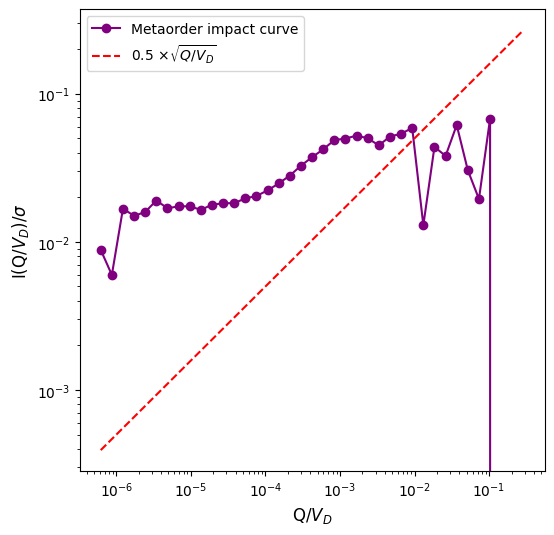

In [73]:
n_intervals = 40

df = metaorder_data.with_columns((pl.col('volume traded') / pl.col('20 AD volume')).alias('x_meta'),
                                 (pl.col('metaorder impact') / pl.col('20 AD volatility')).alias('y_meta'))

x_min = df.select(pl.col('x_meta').min()).item()
x_max = df.select(pl.col('x_meta').max()).item()

bins = np.logspace(np.log10(x_min), np.log10(x_max), n_intervals)
df   = df.with_columns([pl.Series('bin', np.digitize(df['x_meta'].to_numpy(), bins) - 1)])

all_bins = pl.DataFrame({'bin': np.arange(len(bins) - 1)})
binned   = df.group_by('bin').agg(pl.col('y_meta').mean().alias('y_mean')).sort('bin')
binned   = all_bins.join(binned, on = 'bin', how = 'left').sort('bin')

bin_centers = (bins[:-1] + bins[1:]) / 2
binned      = binned.with_columns(x_center = bin_centers)

alpha  = 0.5
binned = binned.with_columns((alpha * pl.col('x_center').sqrt()).alias('sqrt_law'))

def sql_model(x, exp, Y):
    return Y * x ** exp
    
y = np.array(binned['y_mean'])
x = np.array(binned['x_center'])

mask       = (x > 0) & np.isfinite(y)
x_fit      = x[mask]
impact_fit = y[mask]

if len(x_fit) < 10 or len(impact_fit) < 10:
    print('error')
            
try:
    params, covariance = curve_fit(sql_model, x_fit, impact_fit, p0 = [0.5, 0.5], maxfev = 100000)

except RuntimeError:
    print('error')

exp_est = params[0]
Y_est   = params[1]

fitted_curve = sql_model(x, exp_est, Y_est)

n   = len(x_fit)
p   = len(params)          # number of parameters (2 here)
dof = n - p                # degrees of freedom

alpha = 0.05               # 95% CI
tval  = t.ppf(1 - alpha / 2, dof)
se    = np.sqrt(np.diag(covariance))
interval_half_widths = tval * se[0], tval * se[1]

print(f'Y: {Y_est:.3f} \\pm {se[1]:.3f}')
print(f'exponent: {exp_est:.3f} \\pm {se[0]:.3f}')
print(f'{ticker} & {Y_est:.3f} $\\pm$ {se[1]:.3f} & {exp_est:.3f} $\\pm$ {se[0]:.3f}')

fig, ax = plt.subplots(figsize = (6, 6))

ax.set_xscale('log')
ax.set_yscale('log')

#ax.plot(x_bins_centers_meta, y_bins_vals_meta, marker = 'o', color = 'blue', label = 'Metaorder impact curve')
#ax.plot(x_bins_centers_meta, sqrt_law, linestyle = '--', color = 'red', label = r'0.5 $\times \sqrt{Q/V_{D}}$')
ax.plot(binned['x_center'], binned['y_mean'], marker = 'o', color = col, label = 'Metaorder impact curve')
ax.plot(binned['x_center'], binned['sqrt_law'], linestyle = '--', color = 'red', label = r'0.5 $\times \sqrt{Q/V_{D}}$')

ax.set_xlabel(r'Q/$V_{D}$', fontsize = 12)
ax.set_ylabel(r'I(Q/$V_{D}$)/$\sigma$', fontsize = 12)

ax.xaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase = False))
ax.yaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase = False))

plt.legend()

plt.savefig(f'{ticker}_{exchange}_{config}_calibrated_impact_curve.pdf')
b2.put_file(f'{ticker}_{exchange}_{config}_calibrated_impact_curve.pdf', f'figures_2/impact_curves/{exchange}/calibrated/{config}')
b2.get_file(f'figures_2/impact_curves/{exchange}/calibrated/{config}/{ticker}_{exchange}_{config}_calibrated_impact_curve.pdf')

plt.show()


In [74]:
b2.create_folder('figures_2', ensure_exists = True)
b2.create_folder('figures_2/concave_profile', ensure_exists = True)
b2.create_folder(f'figures_2/concave_profile/{exchange}', ensure_exists = True) 
b2.create_folder(f'figures_2/concave_profile/{exchange}/calibrated', ensure_exists = True) 
b2.create_folder(f'figures_2/concave_profile/{exchange}/calibrated/{config}', ensure_exists = True) 

Y: 1.467 \pm 0.025
exponent: 0.764 \pm 0.031
GFI & 1.467 $\pm$ 0.025 & 0.764 $\pm$ 0.031


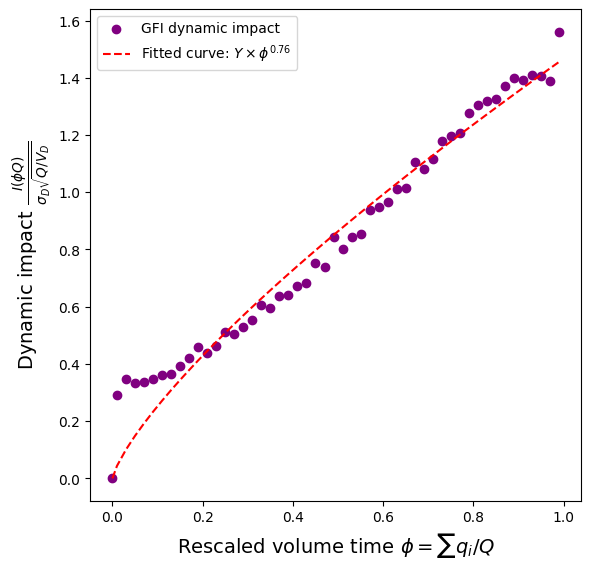

In [75]:
bins = np.linspace(0, 1, 51)
bin_mids = (bins[:-1] + bins[1:]) / 2

df        = concave_data.with_columns(pl.col('phi').cut(bins).alias('bin'))
binned    = df.group_by('bin').agg(pl.col('scaled impact').mean().alias('scaled impact (binned)'))
full_bins = pl.DataFrame({'phi': bin_mids}).with_columns(pl.col('phi').cut(bins).alias('bin'))
df        = full_bins.join(binned, on = 'bin', how = 'left').sort('phi')

scaled_impact_binned = df['scaled impact (binned)']

if len(scaled_impact_binned) < 10:
    print('error')
    
scaled_impact_binned = pl.concat([pl.Series([0.0]), scaled_impact_binned])
bin_mids             = np.insert(bin_mids, 0, 0)
phi                  = bin_mids

def execution_profile_model(phi, exponent, Y):
    return  Y * (phi ** exponent)

phi    = np.array(phi)
impact = np.array(scaled_impact_binned)

mask       = (phi > 0) & np.isfinite(impact)
phi_fit    = phi[mask]
impact_fit = impact[mask]

if len(phi_fit) < 10 or len(impact_fit) < 10:
    print('error')

try:
    params, covariance = curve_fit(execution_profile_model, phi_fit, impact_fit, p0 = [0.5, 1], maxfev = 100000)

except RuntimeError:
    print('error')
    
phi_est      = params[0]
Y_est        = params[1]

fitted_curve = execution_profile_model(bin_mids, phi_est, Y_est)

n   = len(phi_fit)
p   = len(params)          # number of parameters (2 here)
dof = n - p                # degrees of freedom

alpha = 0.05               # 95% CI
tval  = t.ppf(1 - alpha / 2, dof)
se    = np.sqrt(np.diag(covariance))
interval_half_widths = tval * se[0], tval * se[1]

print(f'Y: {Y_est:.3f} \\pm {se[1]:.3f}')
print(f'exponent: {phi_est:.3f} \\pm {se[0]:.3f}')
print(f'{ticker} & {Y_est:.3f} $\\pm$ {se[1]:.3f} & {phi_est:.3f} $\\pm$ {se[0]:.3f}')

fig, ax = plt.subplots(figsize = (6, 6))

ax.scatter(bin_mids, scaled_impact_binned, color = col, marker = 'o', label = f'{ticker} dynamic impact')
ax.set_xlabel(r'Rescaled volume time $\phi = \sum q_i/Q$', fontsize = 14)
ax.set_ylabel(r'Dynamic impact $\frac{I(\phi Q)}{\sigma_{D} \sqrt{Q/V_{D}}}$', fontsize = 14)
ax.plot(bin_mids, fitted_curve, color = 'red', linestyle = '--', label = rf'Fitted curve: $Y \times\phi^{{{phi_est:.2f}}}$')
ax.set_yscale('linear')
ax.legend()

ax.set_box_aspect(1)
plt.tight_layout()

plt.savefig(f'{ticker}_{exchange}_{config}_calibrated_concave_profile.pdf')
b2.put_file(f'{ticker}_{exchange}_{config}_calibrated_concave_profile.pdf', f'figures_2/concave_profile/{exchange}/calibrated/{config}')
b2.get_file(f'figures_2/concave_profile/{exchange}/calibrated/{config}/{ticker}_{exchange}_{config}_calibrated_concave_profile.pdf')

plt.show()


In [76]:
b2.create_folder('figures_2', ensure_exists = True)
b2.create_folder('figures_2/impact_decay', ensure_exists = True)
b2.create_folder(f'figures_2/impact_decay/{exchange}', ensure_exists = True) 
b2.create_folder(f'figures_2/impact_decay/{exchange}/calibrated', ensure_exists = True)
b2.create_folder(f'figures_2/impact_decay/{exchange}/calibrated/{config}', ensure_exists = True)

Y: 3.287 \pm 0.012
exponent: 0.152 \pm 0.003
GFI & 3.287 $\pm$ 0.012 & 0.152 $\pm$ 0.003


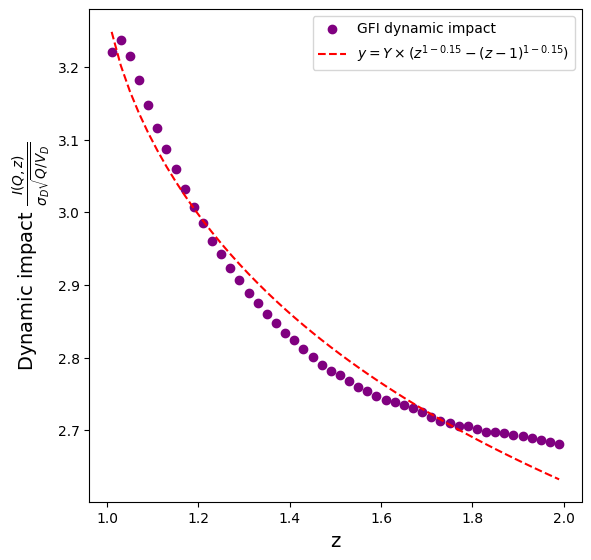

In [77]:
bins = np.linspace(1, 2, 51)
bin_mids = (bins[:-1] + bins[1:]) / 2

df        = decay_data.with_columns(pl.col('z').cut(bins).alias('bin'))
binned    = df.group_by('bin').agg(pl.col('scaled impact').mean().alias('scaled impact (binned)')).sort('bin')
full_bins = pl.DataFrame({'z': bin_mids}).with_columns(pl.col('z').cut(bins).alias('bin'))
df        = full_bins.join(binned, on = 'bin', how = 'left').sort('z')

z         = np.array(bin_mids)
impact    = np.array(df['scaled impact (binned)'])

def decay_model(z, beta, Y):
    return  Y * (z ** (1 - beta) - (z - 1) ** (1 - beta))

mask       = (z > 1) & np.isfinite(impact)
z_fit      = z[mask]
impact_fit = impact[mask]

if len(z_fit) < 10 or len(impact_fit) < 10:
    print('error')

try:
    params, covariance = curve_fit(decay_model, z_fit, impact_fit, p0 = [0.2, 1], maxfev = 100000)

except RuntimeError:
    print('error')  

beta_est = params[0]
Y_est    = params[1]

fitted_curve = decay_model(z_fit, beta_est, Y_est)

n   = len(z_fit)
p   = len(params)          # number of parameters (2 here)
dof = n - p                # degrees of freedom

alpha = 0.05               # 95% CI
tval  = t.ppf(1 - alpha / 2, dof)
se    = np.sqrt(np.diag(covariance))
interval_half_widths = tval * se[0], tval * se[1]

print(f'Y: {Y_est:.3f} \\pm {se[1]:.3f}')
print(f'exponent: {beta_est:.3f} \\pm {se[0]:.3f}')
print(f'{ticker} & {Y_est:.3f} $\\pm$ {se[1]:.3f} & {beta_est:.3f} $\\pm$ {se[0]:.3f}')


fig, ax = plt.subplots(figsize = (6, 6))

ax.scatter(bin_mids, df['scaled impact (binned)'], color = col, marker = 'o', label = f'{ticker} dynamic impact')
ax.plot(z_fit, fitted_curve, color = 'red', linestyle = '--',
        label = rf'$y = Y\times\left(z^{{1-{beta_est:.2f}}} - \left(z-1\right)^{{1-{beta_est:.2f}}}\right)$')
ax.set_xlabel(r'z', fontsize = 14)
ax.set_ylabel(r'Dynamic impact $\frac{I(Q, z)}{\sigma_{D} \sqrt{Q/V_D}}$', fontsize = 14)
ax.legend()

ax.set_box_aspect(1)
plt.tight_layout()

plt.savefig(f'{ticker}_{exchange}_{config}_calibrated_impact_decay.pdf')
b2.put_file(f'{ticker}_{exchange}_{config}_calibrated_impact_decay.pdf', f'figures_2/impact_decay/{exchange}/calibrated/{config}')
b2.get_file(f'figures_2/impact_decay/{exchange}/calibrated/{config}/{ticker}_{exchange}_{config}_calibrated_impact_decay.pdf')

plt.show()


In [18]:
estimation_method = 'psd'
config = 'LMF'
configs = find_configs(data = data, participation_method = 'power',
                           config = 'LMF', estimation_method = 'PSD',
                           lambda_penalty = 1, mix = [1, 1, 1])#.filter(pl.col('ticker') == 'GRT')

alpha_estimate = configs[f'$\\alpha$'] - 1
gamma_estimate = configs[f'$\\gamma$']

In [14]:
configs

ticker,year,N,$\delta$,$\alpha$,$\gamma$,\makecell{$\frac{Q}{V_D}$ \\ exponent},\makecell{$\phi$ \\ exponent},$\beta$,$\mathrm{e}_{M}$ (PSD),$\mathrm{e}_{LMF}$ (PSD)
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""4SI""",2023,50,1.5,1.632324,1.03571,0.331471,0.202451,0.38274,0.305708,0.403386
"""4SI""",2024,20,1.5,1.660229,0.62871,0.315715,0.90898,0.178955,0.244359,0.031519
"""4SI""",2025,50,1.5,1.680371,0.574836,0.170615,0.334226,0.130089,0.202766,0.105535
"""ABG""",2023,500,2.0,1.570508,0.573213,0.097287,0.873287,0.086506,0.302841,0.002706
"""ABG""",2024,40,4.0,1.526709,0.491666,0.208439,0.906395,0.213616,0.247533,0.035043
…,…,…,…,…,…,…,…,…,…,…
"""ZED""",2024,20,3.0,1.331839,0.316821,0.102841,0.777806,-0.003102,0.366264,0.015018
"""ZED""",2025,50,3.0,1.365912,0.385318,0.149043,1.558277,-0.246474,0.847699,0.019406
"""ZZD""",2023,100,4.0,1.508325,0.299046,0.180971,0.652915,0.344288,0.168186,0.209279


In [19]:
b2.create_folder('figures_2', ensure_exists = True)
b2.create_folder('figures_2/alpha_gamma', ensure_exists = True)
b2.create_folder(f'figures_2/alpha_gamma/{exchange}', ensure_exists = True)
b2.create_folder(f'figures_2/alpha_gamma/{exchange}/calibrated', ensure_exists = True)
b2.create_folder(f'figures_2/alpha_gamma/{exchange}/calibrated/{config}', ensure_exists = True)

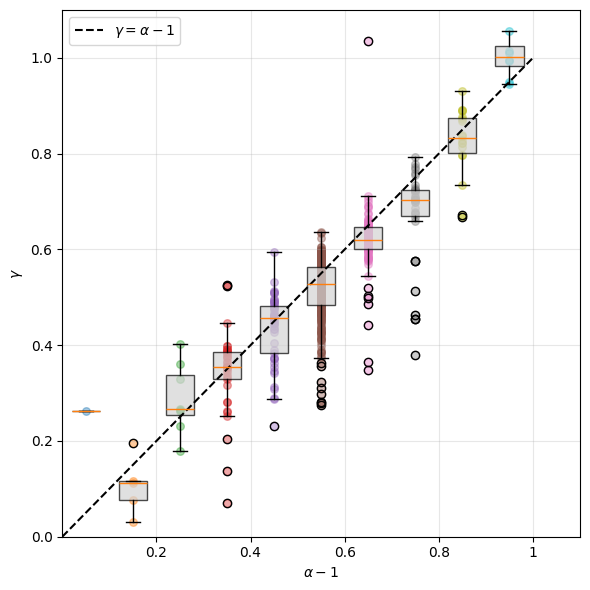

In [116]:
df = pl.DataFrame({'alpha - 1': alpha_estimate, 'gamma': gamma_estimate})

bins = np.linspace(0, 1, 11)

df = df.with_columns(pl.col('alpha - 1').cut(bins).alias('bin'))

bin_mids = (bins[:-1] + bins[1:]) / 2


plt.figure(figsize = (6, 6))

for i in range(len(bin_mids)):
    
    lower = bins[i]
    upper = bins[i+1]

    gamma_vals = df.filter((pl.col('alpha - 1') >= lower) &(pl.col('alpha - 1') < upper)).select('gamma').drop_nulls().to_series().to_numpy()
    
    if len(gamma_vals) == 0:
        continue

    # Boxplot at midpoint
    plt.boxplot(gamma_vals, positions = [bin_mids[i]], widths = 0.06, patch_artist = True, showfliers = True,
                boxprops = dict(facecolor = 'lightgray', alpha = 0.7)) #showmeans = True, meanline = True

    # Scatter points
    plt.scatter(np.full(len(gamma_vals), bin_mids[i]), gamma_vals, alpha = 0.4, s = 30)

# Theoretical line
plt.plot([0, 1], [0, 1], 'k--', label = r'$\gamma = \alpha - 1$')

plt.xticks(ticks = [0.2, 0.4, 0.6, 0.8, 1.0], labels = ['0.2', '0.4', '0.6', '0.8', '1'])
plt.xlabel(r'$\alpha - 1$')
plt.ylabel(r'$\gamma$')
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()

plt.savefig(f'{config}_calibrated_alpha_gamma_{estimation_method}.pdf')
b2.put_file(f'{config}_calibrated_alpha_gamma_{estimation_method}.pdf', f'figures_2/alpha_gamma/{exchange}/calibrated/{config}')
b2.get_file(f'figures_2/alpha_gamma/{exchange}/calibrated/{config}/{config}_calibrated_alpha_gamma_{estimation_method}.pdf')

plt.show()

In [6]:
b2.get_file('top_250.csv')
top_250 = pd.read_csv('top_250.csv')

top_250_tickers = top_250['Ticker'].tolist()

In [7]:
%%time
files = b2.list_files(path = 'data/trades/top_250')

for f in files:
    b2.get_file(f'data/trades/top_250/{f}')

CPU times: user 11.9 s, sys: 5.72 s, total: 17.7 s
Wall time: 1min 37s


In [15]:
def load_stock(parquet):
    try:
        df = pl.read_parquet(parquet)
        return df.sort(['DateTime', 'ExchangeSequenceNo'])
    except FileNotFoundError:
        return None
        
exchange = 'XJSE'
stocks = {
    ticker: df
    for ticker in top_250_tickers
    if (df := load_stock(f'{ticker}_{exchange}.parquet')) is not None
}

In [24]:
participation_method = 'power'
config               = 'metaorder'
b2.create_folder('data', ensure_exists = True)
b2.create_folder('data/metaorders', ensure_exists = True)
b2.create_folder(f'data/metaorders/{exchange}', ensure_exists = True)
b2.create_folder(f'data/metaorders/{exchange}/calibrated', ensure_exists = True)
b2.create_folder(f'data/metaorders/{exchange}/calibrated/{participation_method}', ensure_exists = True)
b2.create_folder(f'data/metaorders/{exchange}/calibrated/{participation_method}/{config}', ensure_exists = True)

In [25]:
%%time
trader_distribution = 'power'
group               = 'year'
config              = 'metaorder'
configs             = find_configs(data = data, participation_method = trader_distribution,
                                   config = 'metaorder', estimation_method = 'PSD',
                                   lambda_penalty = 1, mix = [1, 1, 1])
counter    = 1
start_from = 'BHG'
start      = False
for ticker, stock_data in stocks.items():

    if ticker == start_from:
        start = True

    if not start:
        continue
        
    print(f'{counter}: {ticker}')
    counter += 1

    optimal = configs.filter(pl.col('ticker') == ticker)
    if optimal.is_empty():
        continue

    if trader_distribution == 'homogenous':
        N     = optimal['N'].to_list()
        group = 'year'
        
        if len(N) < 3:
            continue

        stock_features = process_stock_pl(stock_data, N = N, group = group, participation_method = trader_distribution)
        
    if trader_distribution == 'power':
        N        = optimal['N'].to_list()
        alpha_tp = optimal[f'$\\delta$'].to_list()
        group    = 'year'
        
        if len(N) < 3:
            continue

        stock_features = process_stock_pl(stock_data, N = N, group = group, participation_method = trader_distribution, alpha = alpha_tp)

    if not stock_features.is_empty():

        stock_features.write_parquet(f'{ticker}_{exchange}_{trader_distribution}_{config}_metaorder_data_calibrated.parquet')
        b2.put_file(f'{ticker}_{exchange}_{trader_distribution}_{config}_metaorder_data_calibrated.parquet',
                    f'data/metaorders/{exchange}/calibrated/{participation_method}/{config}')


1: BHG
2: BTI
3: ANH
4: PRX
5: CFR
6: GLN
7: AGL
8: ANG
9: NPN
10: GFI
11: SBK
12: FSR
13: CPI
14: VAL
15: MTN
16: VOD
17: IMP
18: S32
19: ABG
20: SLM
21: DSY
22: HAR
23: SHP
24: SSW
25: NPH
26: BID
27: NED
28: SOL
29: OUT
30: RNI
31: KIO
32: NRP
33: REM
34: INP
35: PPH
36: MNP
37: BVT
38: PAN
39: EXX
40: CLS
41: OMU
42: CCO
43: APN
44: GRT
45: QLT
46: WHL
47: TBS
48: MTM
49: SNT
50: ARI
51: MRP
52: DRD
53: RDF
54: HMN
55: INL
56: AVI
57: SRE
58: N91
59: BOX
60: KST
61: TKG
62: VKE
63: RES
64: DCP
65: FFB
66: KRO
67: OPA
68: TFG
69: SRI
70: PMR
71: TGA
72: HYP
73: TRU
74: ADH
75: MTH
76: APH
77: NTC
78: WBC
79: CML
80: LHC
81: NY1
82: DTC
83: LTE
84: BYI
85: GTC
86: EQU
87: MSP
88: OMN
89: JSE
90: PIK
91: HCI
92: ATT
93: GND
94: SPP
95: ITE
96: AFE
97: RLO
98: WBO
99: ARL
100: ISO
101: SUI
102: SAP
103: CVW
104: AFH
105: SDO
106: PPC
107: SAC
108: SSS
109: RBX
110: BLU
111: AEL
112: BAT
113: RCL
114: THA
115: CLI
116: IPF
117: HIL
118: HET
119: OCE
120: TSG
121: CAA
122: DIB
123: RFG
1

In [26]:
participation_method = 'power'
config = 'metaorder'
exchange = 'XJSE'
files = b2.list_files(path = f'data/metaorders/{exchange}/calibrated/{participation_method}/{config}')

for f in files:
    b2.get_file(f'data/metaorders/{exchange}/calibrated/{participation_method}/{config}/{f}')

In [29]:
metaorder_data = pl.scan_parquet('*_XJSE_power_metaorder_metaorder_data_calibrated.parquet').collect()

metaorder_data.head(10)

Date,trader id,metaorder id,Ticker,MIC,Start time,End time,Daily Volume,Intraday Volatility,20 AD volume,20 AD volatility,trade sign,volume traded,number child orders,Mid-price before,Mid-price after,Mid-price after (delayed),Mid-price before (1ms),Mid-price after (1ms),Mid-price after (1ms)(delayed),impact,impact (delayed),impact (1ms),impact (1ms)(delayed),duration (min)
date,i64,i32,str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,i64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-03-07,40,0,"""4SI""","""XJSE""",2023-03-07 15:08:04.763860,2023-03-07 15:08:04.763901,38203.0,0.010825,80494.0,0.016816,1,24817.0,2,27.5,27.5,27.5,27.5,27.5,27.5,0.0,0.0,0.0,0.0,6.8333e-7
2023-08-14,40,2,"""4SI""","""XJSE""",2023-08-14 13:19:44.710847,2023-08-14 15:16:23.792142,506806.0,0.026995,156062.55,0.018586,1,123639.0,3,37.0,39.0,39.5,37.0,39.5,39.5,0.052644,0.065383,0.065383,0.065383,116.651355
2023-06-29,40,0,"""4SI""","""XJSE""",2023-06-29 12:18:49.665764,2023-06-29 13:02:23.621526,31800.0,0.016052,134576.4,0.020316,-1,26238.0,3,26.5,26.0,38.0,null,26.0,38.0,0.019048,-0.360441,null,null,43.565929
2023-08-03,40,0,"""4SI""","""XJSE""",2023-08-03 09:17:57.057105,2023-08-03 10:18:14.987388,362980.0,0.013555,117522.25,0.019275,-1,62881.0,2,39.5,32.0,31.5,39.5,31.5,31.5,0.210565,0.226313,0.226313,0.226313,60.298838
2023-11-09,40,0,"""4SI""","""XJSE""",2023-11-09 09:38:29.547682,2023-11-09 15:12:33.147658,17000.0,0.021236,58876.95,0.025049,-1,9669.0,2,42.5,42.5,26.5,null,41.5,26.5,-0.0,0.472359,null,null,334.06
2023-09-11,40,2,"""4SI""","""XJSE""",2023-09-11 14:23:33.832773,2023-09-11 16:12:58.296570,559870.0,0.016892,346107.65,0.018423,1,20892.0,2,45.0,45.5,48.5,47.0,48.5,48.5,0.01105,0.074901,0.031416,0.031416,109.40773
2023-08-03,40,2,"""4SI""","""XJSE""",2023-08-03 13:33:08.230419,2023-08-03 13:33:42.221471,362980.0,0.013555,117522.25,0.019275,-1,40999.0,2,30.5,30.5,30.5,30.5,30.5,30.5,-0.0,-0.0,-0.0,-0.0,0.566518
2023-08-01,40,0,"""4SI""","""XJSE""",2023-08-01 16:21:33.979547,2023-08-01 16:41:24.943407,23222.0,0.027548,102951.4,0.020566,1,254.0,2,26.5,26.5,26.0,26.5,26.5,26.0,0.0,-0.019048,0.0,-0.019048,19.849398
2023-09-11,40,10,"""4SI""","""XJSE""",2023-09-11 16:12:59.704881,2023-09-11 16:12:59.940799,559870.0,0.016892,346107.65,0.018423,1,40000.0,2,45.0,45.0,45.0,45.0,45.0,45.0,0.0,0.0,0.0,0.0,0.003932


In [30]:
b2.create_folder('figures_2', ensure_exists = True)
b2.create_folder('figures_2/impact_curves', ensure_exists = True)
b2.create_folder(f'figures_2/impact_curves/{exchange}', ensure_exists = True) 
b2.create_folder(f'figures_2/impact_curves/{exchange}/calibrated', ensure_exists = True) 
b2.create_folder(f'figures_2/impact_curves/{exchange}/calibrated/{config}', ensure_exists = True) 

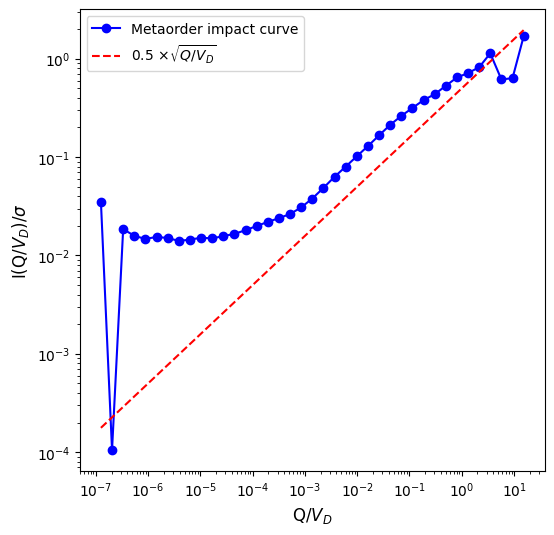

In [32]:
n_intervals = 40

df = metaorder_data.with_columns((pl.col('volume traded') / pl.col('20 AD volume')).alias('x_meta'),
                                 (pl.col('impact') / pl.col('20 AD volatility')).fill_nan(None).alias('y_meta'))

x_min = df.select(pl.col('x_meta').min()).item()
x_max = df.select(pl.col('x_meta').max()).item()

bins = np.logspace(np.log10(x_min), np.log10(x_max), n_intervals)
df   = df.with_columns([pl.Series('bin', np.digitize(df['x_meta'].to_numpy(), bins) - 1)])

all_bins = pl.DataFrame({'bin': np.arange(len(bins) - 1)})
binned   = df.group_by('bin').agg(pl.col('y_meta').mean().alias('y_mean')).sort('bin')
binned   = all_bins.join(binned, on = 'bin', how = 'left').sort('bin')

bin_centers = (bins[:-1] + bins[1:]) / 2
binned      = binned.with_columns(x_center = bin_centers)

alpha  = 0.5
binned = binned.with_columns((alpha * pl.col('x_center').sqrt()).alias('sqrt_law'))

fig, ax = plt.subplots(figsize = (6, 6))

ax.set_xscale('log')
ax.set_yscale('log')

#ax.plot(x_bins_centers_meta, y_bins_vals_meta, marker = 'o', color = 'blue', label = 'Metaorder impact curve')
#ax.plot(x_bins_centers_meta, sqrt_law, linestyle = '--', color = 'red', label = r'0.5 $\times \sqrt{Q/V_{D}}$')
ax.plot(binned['x_center'], binned['y_mean'], marker = 'o', color = 'blue', label = 'Metaorder impact curve')
ax.plot(binned['x_center'], binned['sqrt_law'], linestyle = '--', color = 'red', label = r'0.5 $\times \sqrt{Q/V_{D}}$')

ax.set_xlabel(r'Q/$V_{D}$', fontsize = 12)
ax.set_ylabel(r'I(Q/$V_{D}$)/$\sigma$', fontsize = 12)

ax.xaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase = False))
ax.yaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase = False))

plt.legend()

plt.savefig(f'{exchange}_{config}_calibrated_impact_curve.pdf')
b2.put_file(f'{exchange}_{config}_calibrated_impact_curve.pdf', f'figures_2/impact_curves/{exchange}/calibrated/{config}')
b2.get_file(f'figures_2/impact_curves/{exchange}/calibrated/{config}/{exchange}_{config}_calibrated_impact_curve.pdf')

plt.show()


In [23]:
binned.sort('y_mean')

bin,y_mean,x_center,sqrt_law
i64,f64,f64,f64
0,-0.001446,1.2908e-7,0.00018
3,0.012124,5.6002e-7,0.000374
2,0.012219,3.4336e-7,0.000293
4,0.015292,9.1339e-7,0.000478
5,0.015309,0.000001,0.00061
…,…,…,…
30,NaN,0.305067,0.276164
31,NaN,0.497561,0.35269
32,NaN,0.811517,0.450421


In [ ]:
""""
def sql_model(x, exp, Y):
    return Y * x ** exp
    
y = np.array(binned['y_mean'])
x = np.array(binned['x_center'])

mask       = (x > 0) & np.isfinite(y)
x_fit      = x[mask]
impact_fit = y[mask]

if len(x_fit) < 10 or len(impact_fit) < 10:
    print('error')
            
try:
    params, covariance = curve_fit(sql_model, x_fit, impact_fit, p0 = [0.5, 0.5], maxfev = 100000)

except RuntimeError:
    print('error')

exp_est = params[0]
Y_est   = params[1]

fitted_curve = sql_model(x, exp_est, Y_est)

n   = len(x_fit)
p   = len(params)          # number of parameters (2 here)
dof = n - p                # degrees of freedom

alpha = 0.05               # 95% CI
tval  = t.ppf(1 - alpha / 2, dof)
se    = np.sqrt(np.diag(covariance))
interval_half_widths = tval * se[0], tval * se[1]

print(f'Y: {Y_est:.3f} \\pm {se[1]:.3f}')
print(f'exponent: {exp_est:.3f} \\pm {se[0]:.3f}')
print(f'{ticker} & {Y_est:.3f} $\\pm$ {se[1]:.3f} & {exp_est:.3f} $\\pm$ {se[0]:.3f}')
""""